# Report 2

| Measure | Role |
|---|---|
| **ABC** | Total integrated divergence |
| **DTW** | Residual magnitude error after optimal alignment |
| **ABC − DTW** | Timing component (error absorbed by warping) |
| **Warp path deviation** | Lag: direction and stability of temporal offset |


In [13]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

import similaritymeasures

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1  Load & Clean Data

In [14]:
df = pd.read_csv("hsa_state_new.csv", parse_dates=["time_value"])
df = df.dropna(subset=["state", "hsa_value", "state_value"])
df = df.sort_values(["hsa_id", "time_value"]).reset_index(drop=True)

print(f"Rows       : {len(df):,}")
print(f"States     : {df['state'].nunique()}")
print(f"HSAs       : {df['hsa_id'].nunique()}")
print(f"Date range : {df['time_value'].min().date()} to {df['time_value'].max().date()}")
df.head()

Rows       : 124,551
States     : 38
HSAs       : 671
Date range : 2022-09-25 to 2026-05-03


,time_value,hsa_id,state,hsa_value,state_value,hsa_pop,state_pop,pop_ratio
0,2022-09-25,1,Maryland,0.00,0.26,96475.0,6170738.0,0.015634
1,2022-10-02,1,Maryland,0.00,0.41,96475.0,6170738.0,0.015634
2,2022-10-09,1,Maryland,0.00,0.93,96475.0,6170738.0,0.015634
3,2022-10-16,1,Maryland,0.19,1.80,96475.0,6170738.0,0.015634
4,2022-10-23,1,Maryland,0.70,3.74,96475.0,6170738.0,0.015634


## 2  Helpers

 expects **(n, 2)** arrays — column 0 is the independent variable
(time as numeric days), column 1 is the signal value.

The DTW call returns .  
We traceback through that matrix to recover the warp path for lag analysis.

In [15]:
def make_curve(t_days, values):
    """Stack numeric time and signal into (n, 2) for similaritymeasures."""
    curve = np.zeros((len(t_days), 2))
    curve[:, 0] = t_days
    curve[:, 1] = values
    return curve


def warp_path_from_matrix(dtw_matrix):
    """
    Traceback through the DTW accumulated-cost matrix returned by
    similaritymeasures.dtw() to recover the optimal warp path.

    Returns a list of (i, j) index pairs from start to end.
    """
    n, m = dtw_matrix.shape
    i, j = n - 1, m - 1
    path = [(i, j)]
    while i > 0 or j > 0:
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            candidates = {
                (i - 1, j - 1): dtw_matrix[i - 1, j - 1],
                (i - 1, j    ): dtw_matrix[i - 1, j    ],
                (i,     j - 1): dtw_matrix[i,     j - 1],
            }
            i, j = min(candidates, key=candidates.get)
        path.append((i, j))
    path.reverse()
    return path


def lag_metrics(path):
    """
    Scalar lag statistics from a warp path.

    Diagonal deviation at step k  =  i_k - j_k
      +  HSA index ahead of state → HSA LEADS (early signal)
      -  HSA index behind state   → HSA LAGS  (slow signal)

    Returns
    -------
    mean_lag      : signed average offset  (direction of lead/lag)
    mean_abs_lag  : average absolute displacement  (timing error size)
    lag_variance  : variance of deviations
                    low  = consistent, correctable offset
                    high = erratic, structural disagreement
    max_abs_lag   : worst-case point misalignment
    """
    dev = np.array([i - j for i, j in path], dtype=float)
    return {
        "mean_lag"    : float(np.mean(dev)),
        "mean_abs_lag": float(np.mean(np.abs(dev))),
        "lag_variance": float(np.var(dev)),
        "max_abs_lag" : float(np.max(np.abs(dev))),
    }


print("Helpers ready")

Helpers ready


## 3  Per-HSA Analysis

In [16]:
records = []

groups = list(df.groupby("hsa_id"))
n_total = len(groups)

for idx, (hsa_id, grp) in enumerate(groups):

    if idx % 100 == 0:
        print(f"  {idx}/{n_total} HSAs processed...")

    grp = grp.sort_values("time_value")
    if len(grp) < 4:
        continue

    # ── Build (n, 2) arrays ──────────────────────────────────────────────
    t_days     = (grp["time_value"] - grp["time_value"].min()).dt.days.values.astype(float)
    state_vals = grp["state_value"].values.astype(float)
    hsa_vals   = grp["hsa_value"].values.astype(float)

    # exp_data = ground truth (state), num_data = local signal (hsa)
    exp_data = make_curve(t_days, state_vals)
    num_data = make_curve(t_days, hsa_vals)

    # ── Similarity measures ───────────────────────────────────────────────
    area      = similaritymeasures.area_between_two_curves(exp_data, num_data)
    dtw_dist, dtw_matrix = similaritymeasures.dtw(exp_data, num_data)
    rmse       = math.sqrt(similaritymeasures.mse(exp_data, num_data))

    # ── Decomposition ─────────────────────────────────────────────────────
    timing_component = area - dtw_dist
    timing_share     = timing_component / area if area > 0 else np.nan

    # ── Lag from warp path ────────────────────────────────────────────────
    path = warp_path_from_matrix(dtw_matrix)
    lags = lag_metrics(path)

    records.append({
        "hsa_id"             : hsa_id,
        "state"              : grp["state"].iloc[0],
        "n_obs"              : len(grp),
        "pop_ratio"          : grp["pop_ratio"].iloc[0],
        "abc"                : area,
        "dtw"                : dtw_dist,
        "rmse"                : rmse,
        "timing_component"   : timing_component,
        "magnitude_component": dtw_dist,
        "timing_share"       : timing_share,
        **lags,
    })

hsa_df = pd.DataFrame(records)
print(f"Done — {len(hsa_df)} HSAs")
hsa_df.round(4).head(10)

  0/671 HSAs processed...
  100/671 HSAs processed...
  200/671 HSAs processed...
  300/671 HSAs processed...
  400/671 HSAs processed...
  500/671 HSAs processed...
  600/671 HSAs processed...
Done — 671 HSAs


,hsa_id,state,n_obs,pop_ratio,abc,dtw,rmse,timing_component,magnitude_component,timing_share,mean_lag,mean_abs_lag,lag_variance,max_abs_lag
0,1,Maryland,189,0.0156,908.145,129.91,0.9390,778.235,129.91,0.8570,0.0,0.0,0.0,0.0
1,2,Kentucky,189,0.0996,585.550,83.77,0.6093,501.780,83.77,0.8569,0.0,0.0,0.0,0.0
2,3,Delaware,189,0.4303,312.865,44.75,0.3091,268.115,44.75,0.8570,0.0,0.0,0.0,0.0
3,5,Virginia,189,0.0634,804.965,115.25,0.7654,689.715,115.25,0.8568,0.0,0.0,0.0,0.0
4,7,West Virginia,189,0.1667,543.620,77.84,0.5961,465.780,77.84,0.8568,0.0,0.0,0.0,0.0
5,8,Pennsylvania,105,0.0258,228.410,32.72,0.4581,195.690,32.72,0.8567,0.0,0.0,0.0,0.0
6,9,Maine,189,0.3047,412.825,59.03,0.4658,353.795,59.03,0.8570,0.0,0.0,0.0,0.0
7,10,New York,189,0.0239,448.910,64.22,0.4285,384.690,64.22,0.8569,0.0,0.0,0.0,0.0
8,11,Kentucky,189,0.0154,969.500,138.59,0.9438,830.910,138.59,0.8571,0.0,0.0,0.0,0.0
9,12,Illinois,189,0.0022,1969.870,281.54,2.3384,1688.330,281.54,0.8571,0.0,0.0,0.0,0.0


## 4  State-Level Aggregation

In [17]:
state_df = (
    hsa_df
    .groupby("state")
    .agg(
        n_hsas            =("hsa_id",             "count"),
        mean_abc          =("abc",                 "mean"),
        mean_dtw          =("dtw",                 "mean"),
        mean_rmse          =("rmse",                 "mean"),
        mean_timing       =("timing_component",    "mean"),
        mean_magnitude    =("magnitude_component", "mean"),
        mean_timing_share =("timing_share",        "mean"),
        mean_lag          =("mean_lag",            "mean"),
        mean_abs_lag      =("mean_abs_lag",        "mean"),
        mean_lag_variance =("lag_variance",        "mean"),
        mean_max_lag      =("max_abs_lag",         "mean"),
    )
    .reset_index()
    .sort_values("mean_abc", ascending=False)
)

state_df.round(4)

,state,n_hsas,mean_abc,mean_dtw,mean_rmse,mean_timing,mean_magnitude,mean_timing_share,mean_lag,mean_abs_lag,mean_lag_variance,mean_max_lag
31,Texas,56,1344.3175,193.1564,1.2962,1151.1611,193.1564,0.8563,0.0,0.0,0.0,0.0
16,Minnesota,21,1340.6900,191.6914,1.9252,1148.9986,191.6914,0.8570,0.0,0.0,0.0,0.0
9,Kansas,36,1321.8761,188.9983,1.4366,1132.8778,188.9983,0.8570,0.0,0.0,0.0,0.0
24,North Carolina,30,1318.8000,188.9483,1.0855,1129.8517,188.9483,0.8567,0.0,0.0,0.0,0.0
17,Mississippi,25,1204.8414,172.5648,1.1837,1032.2766,172.5648,0.8567,0.0,0.0,0.0,0.0
37,Wyoming,13,1171.6438,168.0492,1.1227,1003.5946,168.0492,0.8566,0.0,0.0,0.0,0.0
8,Iowa,34,1130.2787,161.7106,1.2906,968.5681,161.7106,0.8569,0.0,0.0,0.0,0.0
22,New Mexico,11,1095.4141,156.7909,1.1492,938.6232,156.7909,0.8568,0.0,0.0,0.0,0.0
11,Louisiana,16,1071.1881,153.8362,1.0188,917.3519,153.8362,0.8563,0.0,0.0,0.0,0.0
3,Georgia,36,1035.2621,148.6361,1.0167,886.6260,148.6361,0.8564,0.0,0.0,0.0,0.0


## 5  Visualisations
### 5.1 ABC vs DTW — Total vs Magnitude Divergence

Points **above** the diagonal: timing error dominates.  
Points **on/below** the diagonal: magnitude error dominates.

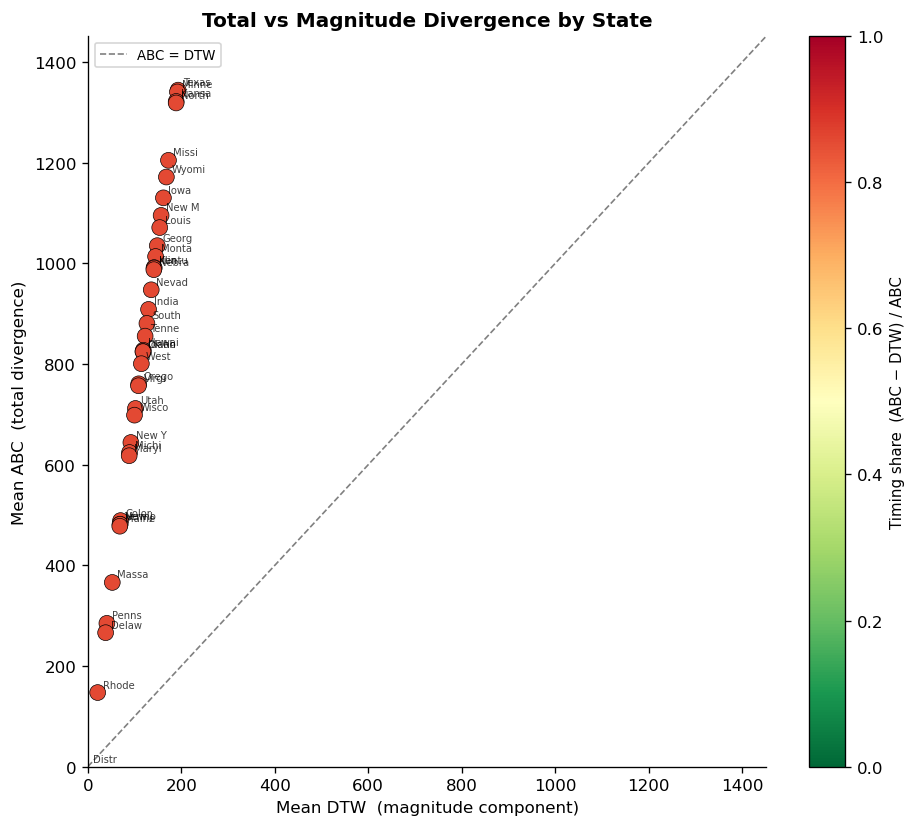

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))

sc = ax.scatter(
    state_df["mean_dtw"],
    state_df["mean_abc"],
    c=state_df["mean_timing_share"],
    cmap="RdYlGn_r", vmin=0, vmax=1,
    s=90, edgecolors="k", linewidths=0.4, zorder=3,
)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Timing share  (ABC − DTW) / ABC", fontsize=9)

lim_max = max(state_df["mean_abc"].max(), state_df["mean_dtw"].max()) * 1.08
ax.plot([0, lim_max], [0, lim_max], "--", color="grey", lw=1, label="ABC = DTW")
ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)

for _, row in state_df.iterrows():
    ax.annotate(row["state"][:5], (row["mean_dtw"], row["mean_abc"]),
                fontsize=6, alpha=0.75, xytext=(3, 3), textcoords="offset points")

ax.set_xlabel("Mean DTW  (magnitude component)", fontsize=10)
ax.set_ylabel("Mean ABC  (total divergence)", fontsize=10)
ax.set_title("Total vs Magnitude Divergence by State", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 5.2 Timing Share per State

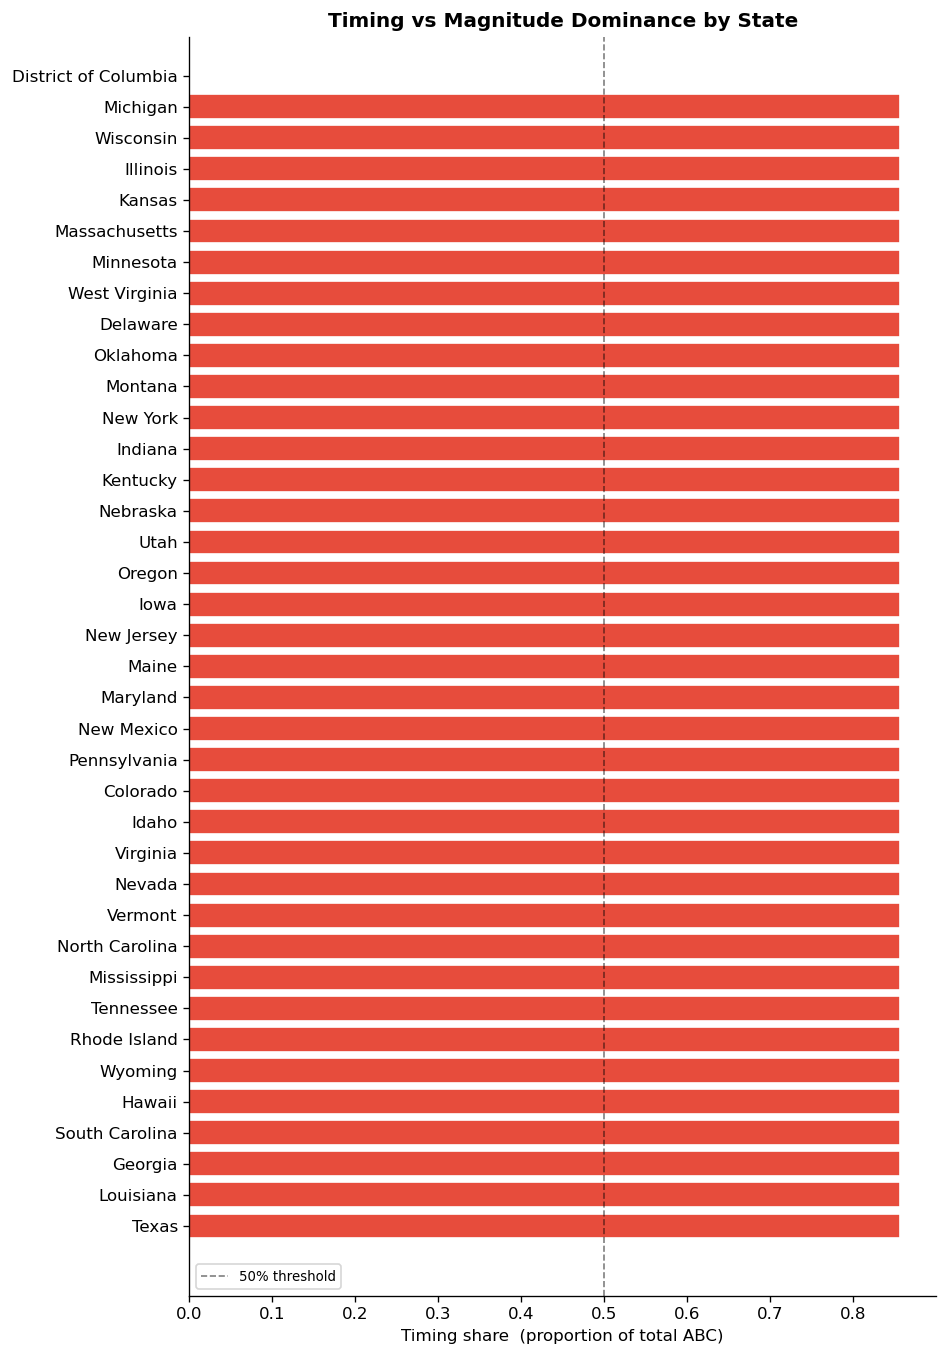

In [19]:
ordered = state_df.sort_values("mean_timing_share")
colors  = ["#e74c3c" if v > 0.5 else "#3498db" for v in ordered["mean_timing_share"]]

fig, ax = plt.subplots(figsize=(8, max(5, len(ordered) * 0.3)))
ax.barh(ordered["state"], ordered["mean_timing_share"], color=colors, edgecolor="white")
ax.axvline(0.5, color="k", lw=1, ls="--", alpha=0.5, label="50% threshold")
ax.set_xlabel("Timing share  (proportion of total ABC)")
ax.set_title("Timing vs Magnitude Dominance by State", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 5.3 Mean Lag and Lag Variance by State

**Mean lag** (signed): positive → HSA leads state (early signal); negative → HSA lags state.  
**Lag variance**: low = consistent correctable offset; high = erratic structural disagreement.

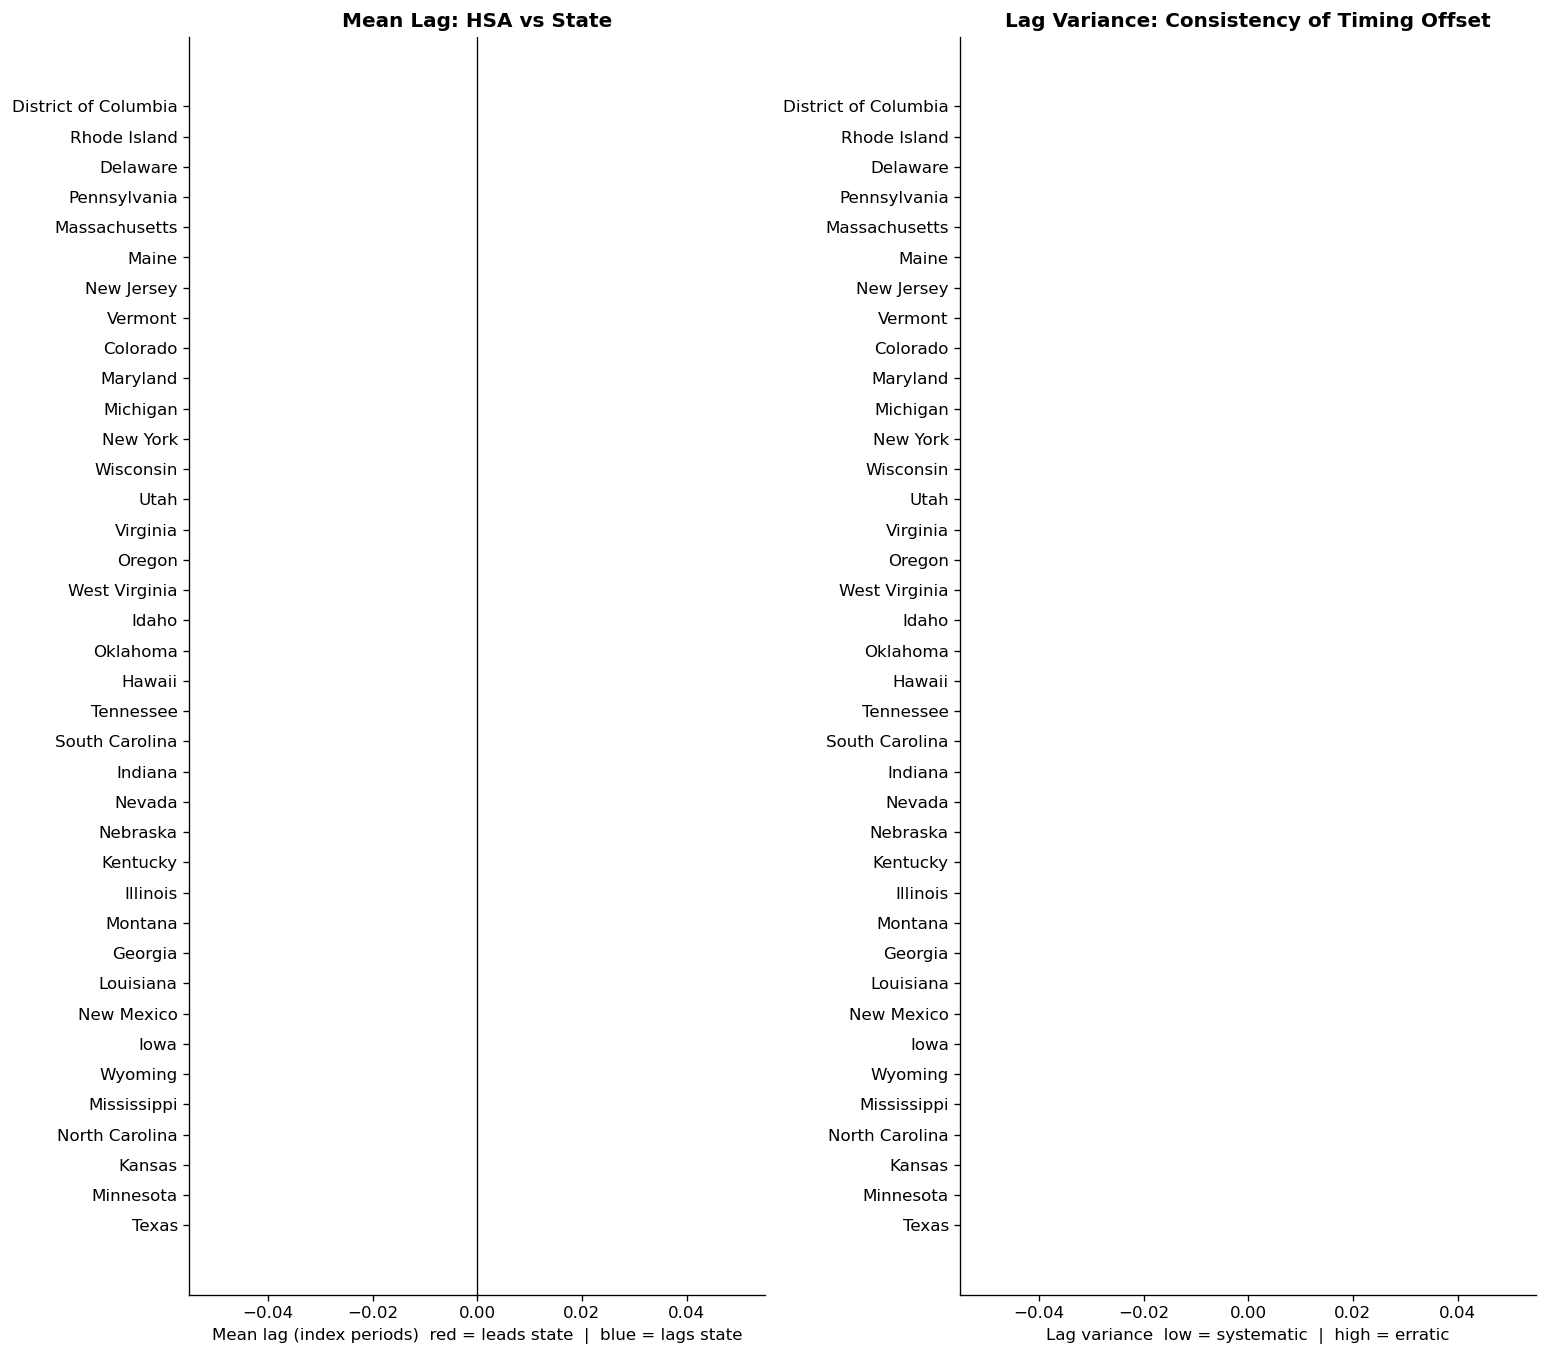

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, max(5, len(state_df) * 0.3)))

ordered_lag = state_df.sort_values("mean_lag")
colors_lag  = ["#e74c3c" if v > 0 else "#3498db" for v in ordered_lag["mean_lag"]]
axes[0].barh(ordered_lag["state"], ordered_lag["mean_lag"],
             color=colors_lag, edgecolor="white")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_xlabel("Mean lag (index periods)  red = leads state  |  blue = lags state")
axes[0].set_title("Mean Lag: HSA vs State", fontweight="bold")

ordered_var = state_df.sort_values("mean_lag_variance")
axes[1].barh(ordered_var["state"], ordered_var["mean_lag_variance"],
             color="#8e44ad", edgecolor="white")
axes[1].set_xlabel("Lag variance  low = systematic  |  high = erratic")
axes[1].set_title("Lag Variance: Consistency of Timing Offset", fontweight="bold")

plt.tight_layout()
plt.show()

### 5.4 Single HSA Deep-Dive

Change  to any  in the dataset.

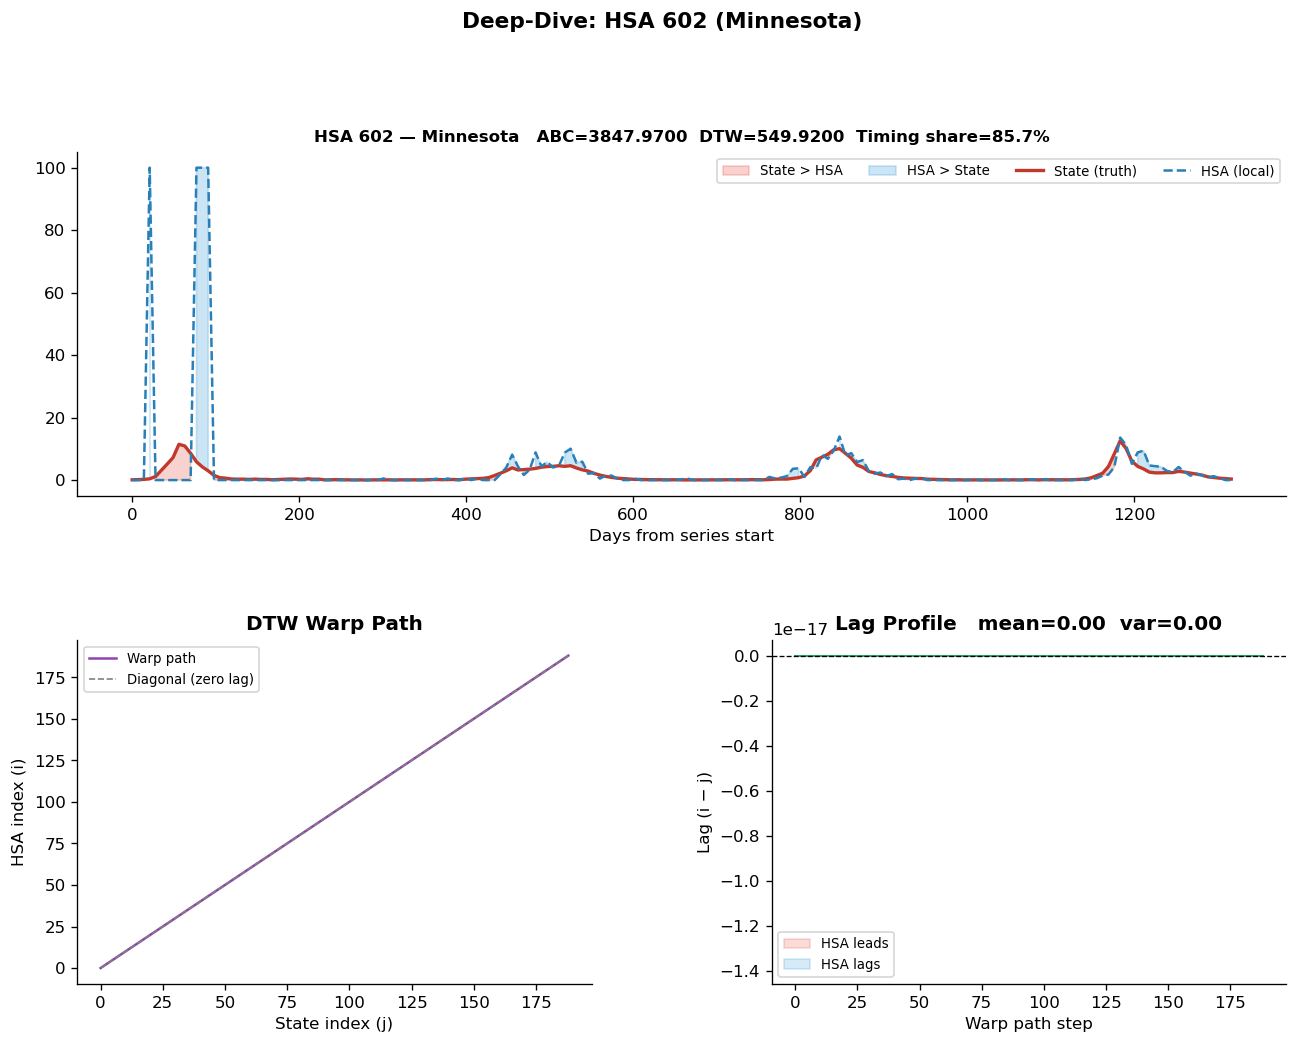

In [24]:
# ── set to any hsa_id you want to inspect ───────────────────────────────
INSPECT_HSA = int(hsa_df.sort_values("abc", ascending=False).iloc[0]["hsa_id"])

grp = df[df["hsa_id"] == INSPECT_HSA].sort_values("time_value")
t_days     = (grp["time_value"] - grp["time_value"].min()).dt.days.values.astype(float)
state_vals = grp["state_value"].values.astype(float)
hsa_vals   = grp["hsa_value"].values.astype(float)

exp_data = make_curve(t_days, state_vals)
num_data = make_curve(t_days, hsa_vals)

area              = similaritymeasures.area_between_two_curves(exp_data, num_data)
dtw_dist, dtw_mat = similaritymeasures.dtw(exp_data, num_data)
path              = warp_path_from_matrix(dtw_mat)
deviations        = np.array([i - j for i, j in path], dtype=float)
row               = hsa_df[hsa_df["hsa_id"] == INSPECT_HSA].iloc[0]

fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

# Panel A — curves + ABC shading
ax0 = fig.add_subplot(gs[0, :])
ax0.fill_between(t_days, state_vals, hsa_vals,
                 where=(state_vals >= hsa_vals),
                 alpha=0.25, color="#e74c3c", label="State > HSA")
ax0.fill_between(t_days, state_vals, hsa_vals,
                 where=(state_vals < hsa_vals),
                 alpha=0.25, color="#3498db", label="HSA > State")
ax0.plot(t_days, state_vals, color="#c0392b", lw=2,   label="State (truth)")
ax0.plot(t_days, hsa_vals,   color="#2980b9", lw=1.5, label="HSA (local)", ls="--")
ax0.set_title(
    f"HSA {INSPECT_HSA} — {row['state']}   "
    f"ABC={area:.4f}  DTW={dtw_dist:.4f}  "
    f"Timing share={row['timing_share']:.1%}",
    fontweight="bold", fontsize=10
)
ax0.set_xlabel("Days from series start")
ax0.legend(fontsize=8, ncol=4)

# Panel B — warp path vs diagonal
ax1 = fig.add_subplot(gs[1, 0])
pi = [p[0] for p in path]
pj = [p[1] for p in path]
ax1.plot(pj, pi, color="#8e44ad", lw=1.5, label="Warp path")
ax1.plot([0, len(t_days)-1], [0, len(t_days)-1], "--", color="grey",
         lw=1, label="Diagonal (zero lag)")
ax1.set_xlabel("State index (j)")
ax1.set_ylabel("HSA index (i)")
ax1.set_title("DTW Warp Path", fontweight="bold")
ax1.legend(fontsize=8)

# Panel C — lag profile over time
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(range(len(deviations)), deviations, color="#27ae60", lw=1.2)
ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.fill_between(range(len(deviations)), deviations, 0,
                 where=(deviations > 0), alpha=0.2, color="#e74c3c", label="HSA leads")
ax2.fill_between(range(len(deviations)), deviations, 0,
                 where=(deviations < 0), alpha=0.2, color="#3498db", label="HSA lags")
ax2.set_xlabel("Warp path step")
ax2.set_ylabel("Lag (i − j)")
ax2.set_title(
    f"Lag Profile   mean={row['mean_lag']:.2f}  var={row['lag_variance']:.2f}",
    fontweight="bold"
)
ax2.legend(fontsize=8)

plt.suptitle(f"Deep-Dive: HSA {INSPECT_HSA} ({row['state']})",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6  Export Results

In [ ]:
hsa_df.to_csv("hsa_metrics.csv", index=False)
state_df.to_csv("state_metrics.csv", index=False)
print("Saved: hsa_metrics.csv  |  state_metrics.csv")